Grace Mwai
# Titanic Dataset training
_**Feature Engineering training using titanic data set**_


# Importing Pandas, NumPy and Matplotlib
_**importing pandas which provides the structure for the data, NumPy which provides the mathematical processing power, and Matplotlib that provides the visual diagnostic tools to verify our data engineering before modeling begins.**_

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Loading file into df_titanic

In [4]:
df_titanic=pd.read_csv('titanic.csv')

In [5]:
df_titanic_age = pd.read_csv('Titanic_Ages - Ages.csv')

# Return the first 5 rows

In [6]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df_titanic_age.head(5)

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


_**This command prints a quick summary of the dataset's structure**_

In [8]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


In [9]:
df_titanic_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    264 non-null    object
 1   Age     264 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.2+ KB


In [10]:
age_lookup=df_titanic_age.set_index('Name')['Age']

In [11]:
df_titanic['Age']= df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

In [12]:
df_titanic[df_titanic['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.05,NaN,S


In [13]:
mask=df_titanic['Name'].str.contains('Peduzzi, Mr. Josep',na=False)
df_titanic.loc[mask, 'Age']=24


In [14]:
df_titanic[df_titanic['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


_**This code splits the main dataset into two separate parts(x- the features and y - the target)**_

In [15]:
x=df_titanic.drop(['Cabin','Survived'],axis=1)
y=df_titanic['Survived']

_**Displays the first 5 rows of our new features dataset**_ 

In [16]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


_**Displays the first 5 records of our target variable**_

In [17]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

_**This code finds all missing or blank values (`NaN`) in the `Age` column and fills them in with the (median age) of all passengers. It is used because  median is the middle value of the data. It is safer to use than the average (mean) because it is not skewed by a few extremely old or young passengers.**_

In [18]:
x['Age']=x['Age'].fillna(x['Age'].median())


_**This code finds any missing values (`NaN`) in the `Fare` column and replaces them with the (median ticket price) of all passengers. We use median because Ticket prices can have extreme outliers (like a few ultra-wealthy passengers paying massive ticket prices). The median prevents these outliers from skewing our replacement value.**_

In [19]:
x['Fare'] = x['Fare'].fillna(x['Fare'].median())

##  Imputing Missing Values (`x['Embarked'].fillna()`)

_**This code finds any missing values (`NaN`) in the `Embarked` column (the port where a passenger boarded the ship) and fills them using the mode. We use mode because unlike age or ticket price, `Embarked` contains text categories (`S`, `C`, `Q`) rather than numbers. You cannot calculate an average port. Instead, the mode calculates the most frequently occurring value in that column to fill in the missing gaps.**_

In [20]:
x['Embarked'] =x['Embarked'].fillna(x['Embarked'].mode(0))

##  Visualizing Class Distribution (`plt.bar`)
 _**This code builds and displays a bar chart showing the total count of passengers who survived (`1`) versus those who did not (`0`).**_

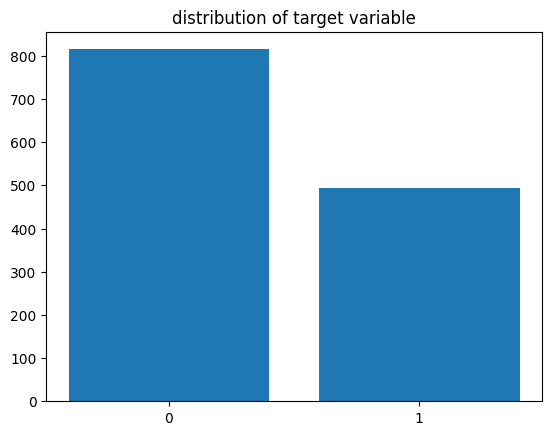

In [21]:
x_plot=y.value_counts()
plt.bar(x_plot.index,x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show()

##  Importing LabelEncoder
_**This imports the `LabelEncoder` tool from the Scikit-Learn library.It is used to convert categorical text labels (like words) into integers (numbers like `0`, `1`, `2`) so our machine learning model can calculate them.**_ 



In [22]:
from sklearn.preprocessing import LabelEncoder

##  Automating Category Conversion with a Loop
_**This code creates a brand-new dataset called `train` and loops through every column in our features matrix (`X`). If a column contains text data (`dtype == 'object'`), the `LabelEncoder` automatically converts the words into integers (like `0`, `1`, `2`). If a column already contains numbers, it leaves them completely alone and copies them over as-is.
We use a loop so that instead of manually encoding columns like `Sex` and `Embarked` one by one, this automated process can handle all text columns across the entire dataset simultaneously.**_

In [23]:
train=pd.DataFrame()
label=LabelEncoder()
for c in x.columns:
    if(x[c].dtype=='object'):
        train[c]=label.fit_transform(x[c])
    else:
        train[c]=x[c]

In [31]:
train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,155,1,22.0,1,0,720,7.2500,2
1,2,1,286,0,38.0,1,0,816,71.2833,0
2,3,3,523,0,26.0,0,0,914,7.9250,2
3,4,1,422,0,35.0,1,0,65,53.1000,2
4,5,3,22,1,35.0,0,0,649,8.0500,2


##  Reviewing the Original Baseline Features (`x.head()`)
_**It displays the first 5 rows of our original features dataset (`x`).**_

In [24]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [26]:
def logistic(x,y):
    x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
    lr= LogisticRegression()
    lr.fit(x_train,y_train)
    y_pre=lr.predict(x_test)
    print('Accuracy : ',accuracy_score(y_test,y_pre))

In [27]:
logistic(train,y)

Accuracy :  0.8206106870229007


/home/student/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Method 2 One hot encoding


In [28]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
train2 = pd.DataFrame()
columns_to_Encode = ['Sex', 'Embarked']
for c in x.columns:
    if c in columns_to_Encode:
        ohe_cols = pd.get_dummies(x[c], prefix=c, dtype=np.int8)
        train2 = pd.concat([train2, ohe_cols], axis=1)
    elif(x[c].dtype=='object'):
        train2[c]=label.fit_transform(x[c])
    else:
        train2[c] = x[c]

In [41]:
train2.head()

,PassengerId,Pclass,Name,Sex_female,Sex_male,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,3,155,0,1,22.0,1,0,720,7.2500,0,0,1
1,2,1,286,1,0,38.0,1,0,816,71.2833,1,0,0
2,3,3,523,1,0,26.0,0,0,914,7.9250,0,0,1
3,4,1,422,1,0,35.0,1,0,65,53.1000,0,0,1
4,5,3,22,0,1,35.0,0,0,649,8.0500,0,0,1


In [36]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [38]:
def logistic(x,y):
    x_train2,x_test,y_train2,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
    lr= LogisticRegression()
    lr.fit(x_train2,y_train2)
    y_pre=lr.predict(x_test)
    print('Accuracy : ',accuracy_score(y_test,y_pre))

In [39]:
logistic(train2,y)

Accuracy :  0.8244274809160306


/home/student/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
